In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score, accuracy_score, confusion_matrix,f1_score


In [140]:
train = pd.read_csv('smartPhone_train.csv')
test = pd.read_csv('smartPhone_test.csv')
submit_sample = pd.read_csv('smartPhone_sample_submission.csv')

<h1>Understanding the Data</h1>

In [96]:
train.head(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [97]:
test.head(5)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [6]:
train.isnull().sum()


id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [7]:
test.isnull().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

In [8]:
test.dtypes

id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
dtype: object

<H1>EDA</H1>

<Axes: xlabel='daily_screen_time_hours', ylabel='addicted_label'>

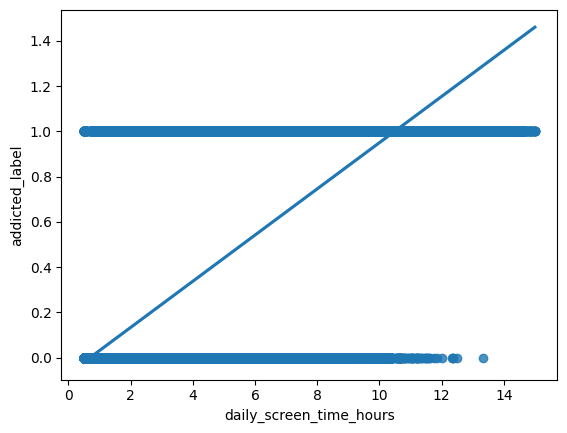

In [9]:
sns.regplot(x = 'daily_screen_time_hours',y='addicted_label',data = train)

<Axes: xlabel='social_media_hours', ylabel='addicted_label'>

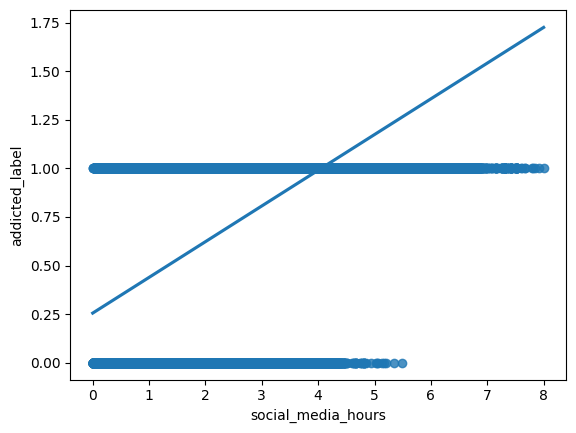

In [10]:
sns.regplot(x = 'social_media_hours',y='addicted_label',data = train)

DTypePromotionError: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

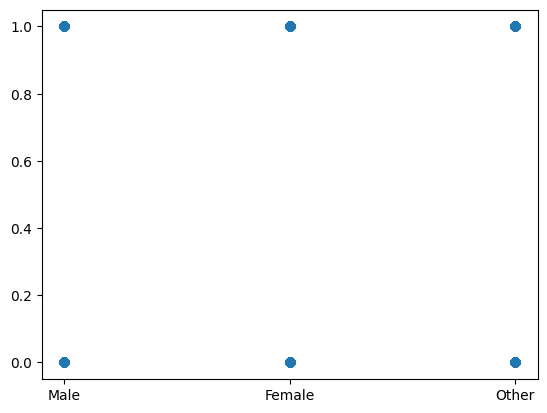

In [12]:
sns.regplot(x= 'gender',y = 'addicted_label',data = train)

<Axes: xlabel='count', ylabel='gender'>

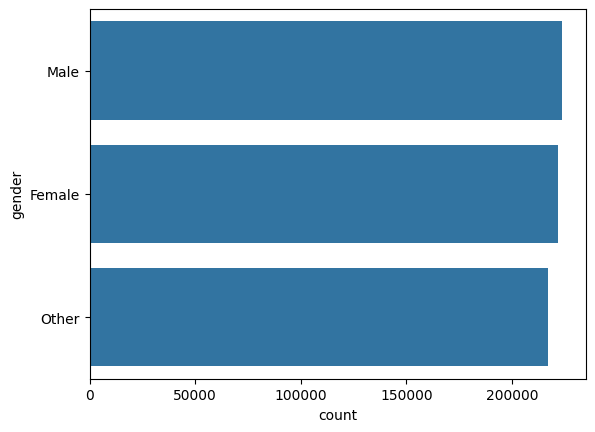

In [ ]:
sns.countplot(train['gender'])

<Axes: xlabel='app_opens_per_day', ylabel='addicted_label'>

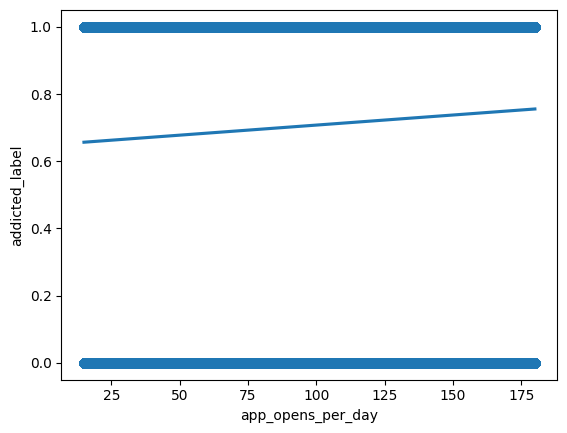

In [13]:
sns.regplot(x = 'app_opens_per_day',y='addicted_label',data = train)


<h1>DATA CLEANING</H1>

In [141]:
train.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [142]:
mean_impute = SimpleImputer(missing_values=np.nan, strategy='mean')

In [143]:
train.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [144]:
train[['age','work_study_hours','daily_screen_time_hours','gaming_hours','social_media_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time']] = mean_impute.fit_transform(train[['age','work_study_hours','daily_screen_time_hours','gaming_hours','social_media_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time']])

In [145]:
#mean replacement 
test[['age','work_study_hours','daily_screen_time_hours','gaming_hours','social_media_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time']] = mean_impute.transform(test[['age','work_study_hours','daily_screen_time_hours','gaming_hours','social_media_hours','sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time']])

In [146]:
test.isnull().sum()

id                             0
age                            0
daily_screen_time_hours        0
social_media_hours             0
gaming_hours                   0
work_study_hours               0
sleep_hours                    0
notifications_per_day          0
app_opens_per_day              0
weekend_screen_time            0
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

<H3>STRING COLUMNS REPLACEMENT</H3>

In [147]:
mode_impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [148]:
train[['gender','stress_level','academic_work_impact']] = mode_impute.fit_transform(train[['gender','stress_level','academic_work_impact']])

In [149]:
test[['gender','stress_level','academic_work_impact']] = mode_impute.transform(test[['gender','stress_level','academic_work_impact']])

In [150]:
train['gender'].value_counts()

gender
Male      252696
Female    221595
Other     217078
Name: count, dtype: int64

In [151]:
train['stress_level'].value_counts()

stress_level
High      276021
Low       207783
Medium    207565
Name: count, dtype: int64

In [152]:
train['academic_work_impact'].value_counts()

academic_work_impact
Yes    374790
No     316579
Name: count, dtype: int64

In [153]:
train['academic_work_impact']=train['academic_work_impact'].map({'Yes':1,'No':0})

In [154]:
test['academic_work_impact'].value_counts()
test['academic_work_impact']=test['academic_work_impact'].map({'Yes':1,'No':0})

In [155]:
encoder = OrdinalEncoder(categories=[['Low','Medium','High']])

In [156]:
train[['stress_level']] = encoder.fit_transform(train[['stress_level']])

In [157]:
test[['stress_level']] = encoder.transform(test[['stress_level']])

In [158]:
gender_encodec = pd.get_dummies(train['gender'],drop_first=True,dtype = int)

In [159]:
train = pd.concat([train,gender_encodec],axis = 1)

In [160]:
train.drop(columns='gender',inplace=True)

In [161]:
gender_encod_test = pd.get_dummies(test['gender'],drop_first=True,dtype=int)

In [162]:
test = pd.concat([test,gender_encod_test],axis=1)

In [163]:
test.drop(columns = 'gender',inplace=True)

In [164]:
train.head(3)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,Male,Other
0,0,24.0,7.640865,1.830000,1.590000,2.110000,7.46,122.0,38.0,8.630000,1.0,0,1,1,0
1,1,19.0,5.970000,1.080000,1.459265,3.030000,8.22,76.0,19.0,9.479866,1.0,0,0,0,0
2,2,18.0,5.090000,2.471038,1.459265,2.366971,6.25,134.0,60.0,7.470000,0.0,1,0,0,0


In [165]:
test.head(3)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,Male,Other
0,691369,30.000000,9.340000,2.471038,0.770000,4.09,7.15,153.0,16.0,9.479866,1.0,1,0,1
1,691370,26.615408,7.640865,1.910000,1.459265,1.20,8.67,239.0,148.0,10.680000,2.0,0,0,0
2,691371,26.000000,8.480000,3.640000,1.459265,3.39,7.47,106.0,123.0,9.479866,2.0,0,1,0


<h1>DATA SPLIT</h1>

In [170]:
x = train.drop(columns=['addicted_label','id'])
#X = train.drop(columns='id')
y = train['addicted_label']



<h3>CREATE A SMALL DATASET</H3>

In [171]:
x_train,x_test, y_train,y_test = train_test_split(x,y,random_state=42, test_size=0.25)

In [172]:
x_small,_,y_small,_ = train_test_split(x,y,train_size=50000, stratify=y,random_state=42 )

In [173]:
x_small_train, x_val, y_small_train, y_val = train_test_split(x_small,y_small, test_size=0.2,random_state=42)

<H1>MODELING</h1>

<h1>1.LOGISTIC REGRESSION</h1>

In [174]:
model_logistic = LogisticRegression(max_iter=1000,random_state=42)

In [175]:
model_logistic.fit(x_small_train,y_small_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [176]:
y_score_log = model_logistic.predict_proba(x_val)[:,1]

In [177]:
print('AUC - SCORE IS : ',roc_auc_score(y_val,y_score_log))

AUC - SCORE IS :  0.9106657496794791


In [178]:
# trying it with multiple c values
c = [0.01,0.1,1,10,100]

In [132]:
for reg in c:
    model_log_2 = LogisticRegression(
        C = reg,
        max_iter=1000,
        random_state=42
    )
    model_log_2.fit(x_small_train,y_small_train)
    y_score_log_2 = model_log_2.predict_proba(x_val)[:,1]
    auc = roc_auc_score(y_val,y_score_log_2)
    print(f"C={c}: {auc:.6f}")

c:\Users\Ahmad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=[0.01, 0.1, 1, 10, 100]: 0.891966


c:\Users\Ahmad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=[0.01, 0.1, 1, 10, 100]: 0.892654


c:\Users\Ahmad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=[0.01, 0.1, 1, 10, 100]: 0.892517


c:\Users\Ahmad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=[0.01, 0.1, 1, 10, 100]: 0.891423
C=[0.01, 0.1, 1, 10, 100]: 0.892755


c:\Users\Ahmad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<h3>TRAINING THE MODEL ON ALL THE DATA</h3>

In [179]:
logistic_model = LogisticRegression(
    C =1,
    max_iter=1000,
    random_state=42
)

In [180]:
logistic_model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [181]:
# validation
y_score_2 = logistic_model.predict_proba(x_test)[:,1]

In [182]:
print('Validation AUC-ROC: ',roc_auc_score(y_test,y_score_2))

Validation AUC-ROC:  0.9113824748946477


In [188]:
test_score1 = logistic_model.predict_proba(test.drop(columns='id'))[:, 1]
submit_sample['addicted_label'] = test_score1

In [193]:
submit_sample['addicted_label'].isnull().sum()

np.int64(0)

<h3>SUBMISSION LOGISTIC RERESSION</h3>

In [195]:
submit_sample.to_csv("submission1(LR).csv", index=False)